In [195]:
import sys
import pickle
import copy

import statsmodels.api as sm
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns

import pypsa
import cartopy.crs as ccrs
import cartopy


from tqdm import tqdm

sys.path.append('../power_system_split/')
import visualisation
import utils

path_to_pypsa_network = '../data/European_networks/'
path_to_cascade_results = '../results/cascade_results/'
path_to_vis_results = '../results/split_visualization/'
path_to_pre_outage = '../results/pre_outage_data/'
path_to_eval_results = '../results/evaluation_results/'
save_path = '../figures/'


# Setup

In [2]:
# Colors for plotting taken from Pypsa
colors = {
    "onwind": "#235ebc",
    'offwind': "#6895dd",
    'offwind-ac': "#6895dd",
    'offwind-dc': "#74c6f2",
    "ror": "#4adbc8",
    'solar': "#f9d002",
    "OCGT": "#d35050",
    "CCGT": "#b20101",
    "Nuclear": "#ff9000",
    "nuclear": "#ff9000",
    "coal": "#707070",
    "lignite": "#9e5a01",
    "biomass": '#0c6013',
    'geothermal': '#ba91b1',
    "oil": "#262626"}


In [3]:
snet_index = 0
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network +
                           'elec_s_800_ec_lv1.0_Co2L0.5-3H.nc')
G = utils.build_networkx_graph(network, snet_index=snet_index)
pos = nx.get_node_attributes(G, 'pos')
criterion = 'nodes'


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [4]:
co2ls = np.arange(0.0, 0.99, 0.05)
selected_co2ls = np.array([0.00, 0.3, 0.6, 0.95])


# Figure 2

In [7]:
carrier_types = ['CCGT', 'OCGT', 'biomass', 'coal', 'geothermal', 'lignite', 'nuclear',
                 'offwind-ac', 'offwind-dc', 'oil', 'onwind', 'ror', 'solar'],
generation_by_carrier_and_co2l = pd.DataFrame(index=pd.Index(*carrier_types),
                                              columns=['{0:.2f}'.format(co2l) for i, co2l in enumerate(co2ls)])
objectives = np.zeros(len(co2ls))
for i, level in enumerate(co2ls):
    n = pypsa.Network()
    co2lstr = '{0:.2f}'.format(level)
    level = np.round(level, 2)
    n.import_from_netcdf(path_to_pypsa_network +
                         f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')
    generation_by_carrier_and_co2l[co2lstr] = n.generators_t.p.T.groupby(
        n.generators["carrier"]).sum().sum(axis=1)
    objectives[i] = n.objective


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will b

/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.95-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:numexpr.utils:Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.
/home/jkrus

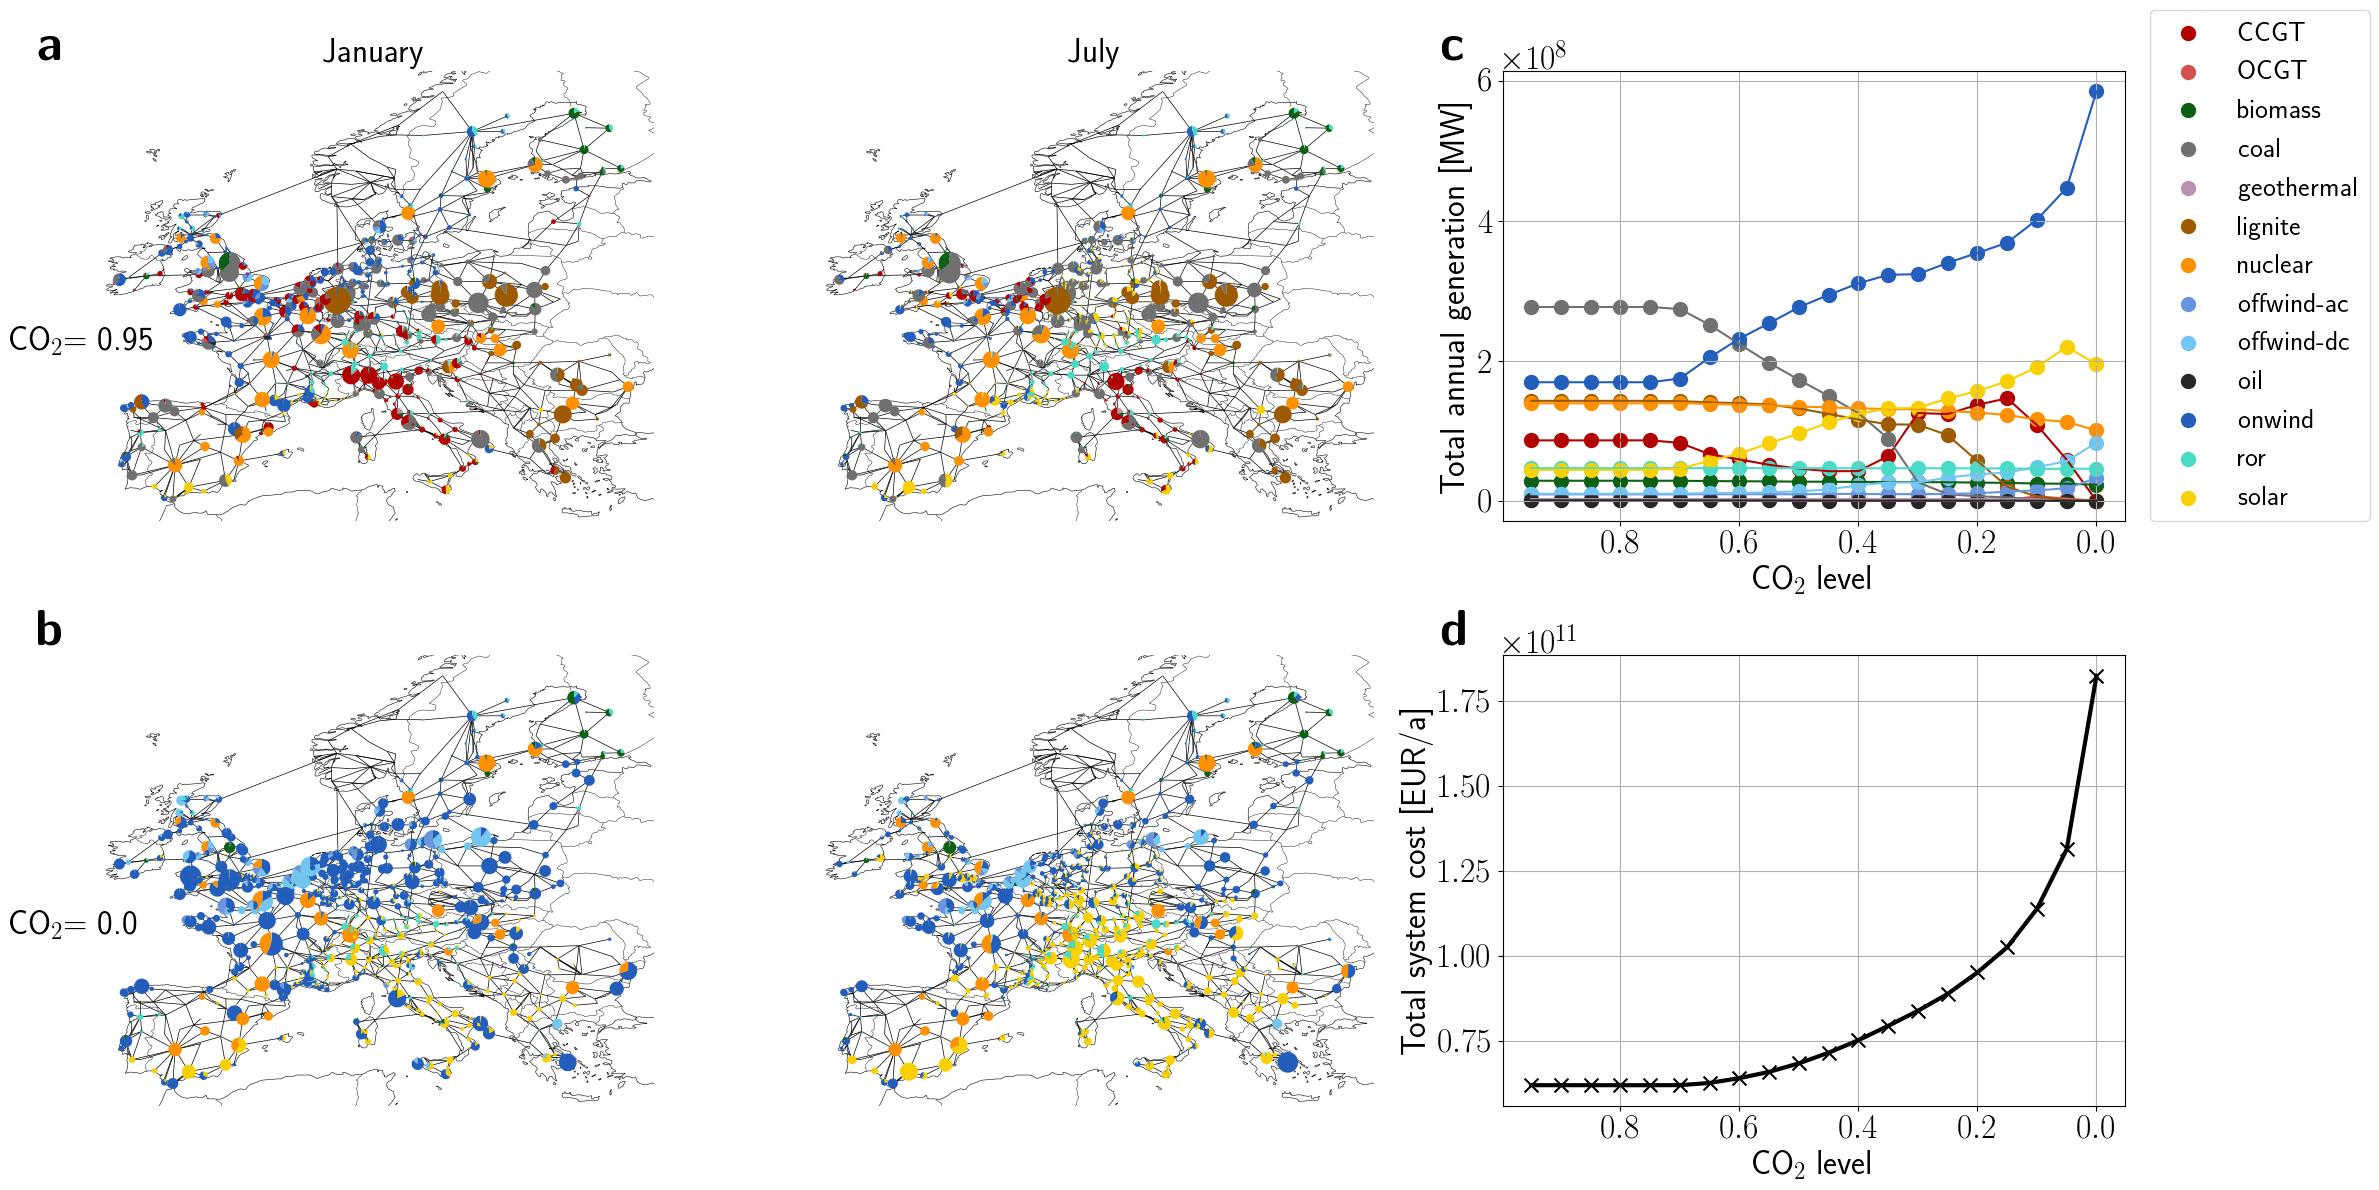

In [8]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.95, 0.0]

f = plt.figure(figsize=(24, 12))

gs = GridSpec(2, 3, figure=f)

ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
       for i in range(2)]
ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
       for i in range(2)]
axs = [ax1, ax2]

ax3 = f.add_subplot(gs[0, 2])
ax4 = f.add_subplot(gs[1, 2])

f.subplots_adjust(hspace=0.05, wspace=0.05)

#f,ax = plt.subplots(2,3,figsize = (24,12),subplot_kw = {"projection":ccrs.PlateCarree()})
vmax = 3.2e2
months = [1, 7]

labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

for i, ind in enumerate(target_levels):
    n = pypsa.Network()
    n.import_from_netcdf(path_to_pypsa_network +
                         f'elec_s_800_ec_lv1.0_Co2L{ind}-3H.nc')

    for j, month in enumerate(months):

        axs[i][j].set_ylim([0, vmax])
        current_snapshots = n.snapshots[n.snapshots.month == month]

        n.plot(bus_sizes=n.generators_t.p.loc[current_snapshots].sum().groupby([n.generators["bus"], n.generators["carrier"]]).sum()/2e6,
               line_colors='black',
               link_colors='black',
               link_widths=0.5,
               line_widths=0.5,
               ax=axs[i][j])

        if i == 0:
            axs[i][j].set_title(current_snapshots.month_name()[0], fontsize=24)

        axs[i][j].text(0 - 0.1, 1+0.05,
                       labels[i][j],
                       fontsize=36,
                       weight='bold',
                       verticalalignment='center',
                       transform=axs[i][j].transAxes)


axs[0][0].text(0 - 0.15, 0.4,
               r'CO$_2$= '+str(0.95),
               fontsize=24,
               verticalalignment='center',
               transform=axs[0][0].transAxes)

axs[1][0].text(0 - 0.15, 0.4,
               r'CO$_2$= '+str(0.0),
               fontsize=24,
               verticalalignment='center',
               transform=axs[1][0].transAxes)

##############################
co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)

for row in generation_by_carrier_and_co2l.iterrows():
    ax3.scatter(co2s[index],
                (row[1].values)[index],
                color=colors[row[0]],
                label=row[0],
                s=100)

    ax3.plot(co2s[index],
             (row[1].values)[index],
             color=colors[row[0]])


ax3.invert_xaxis()
ax3.tick_params(axis='both', which='both', labelsize=24)
ax3.set_xlabel(r'$\text{CO}_2 \text{ level}$',  fontsize=24)
ax3.set_ylabel(r'Total annual generation [MW]', fontsize=24)

ax3.grid(True)
ax3.yaxis.offsetText.set_fontsize(24)
ax3.text(0 - 0.1, 1+0.05,
         labels[0][2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
ax4.plot(co2ls,
         objectives,
         lw=3,
         color='black')
ax4.scatter(co2ls,
            objectives,
            marker='x',
            color='black',
            s=100)
ax4.invert_xaxis()
ax4.tick_params(axis='both', which='both', labelsize=24)
ax4.set_xlabel(r'$\text{CO}_2 \text{ level}$',  fontsize=24)
ax4.set_ylabel(r'Total system cost [EUR/a]', fontsize=24)

ax4.grid(True)
ax4.yaxis.offsetText.set_fontsize(24)
ax4.text(0 - 0.1, 1+0.05,
         labels[1][2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax4.transAxes)


ax3.legend(fontsize=20, loc=(1.04, 0))
# ax3.set_yscale('log')

plt.tight_layout()
plt.savefig(save_path+'Generation_mix_versus_co2level.pdf',
            bbox_inches='tight')

# plt.show()


# Figure 3 & Figure 9

In [197]:
inertia_time = np.load(path_to_pre_outage +
                       'inertia_time_series_all_co2ls.npy')
inertia_generation = np.load(
    path_to_pre_outage + 'min_max_nodal_inertia_generation_co2l_95_and_00.npy')
target_levels = [0.95, 0.00]


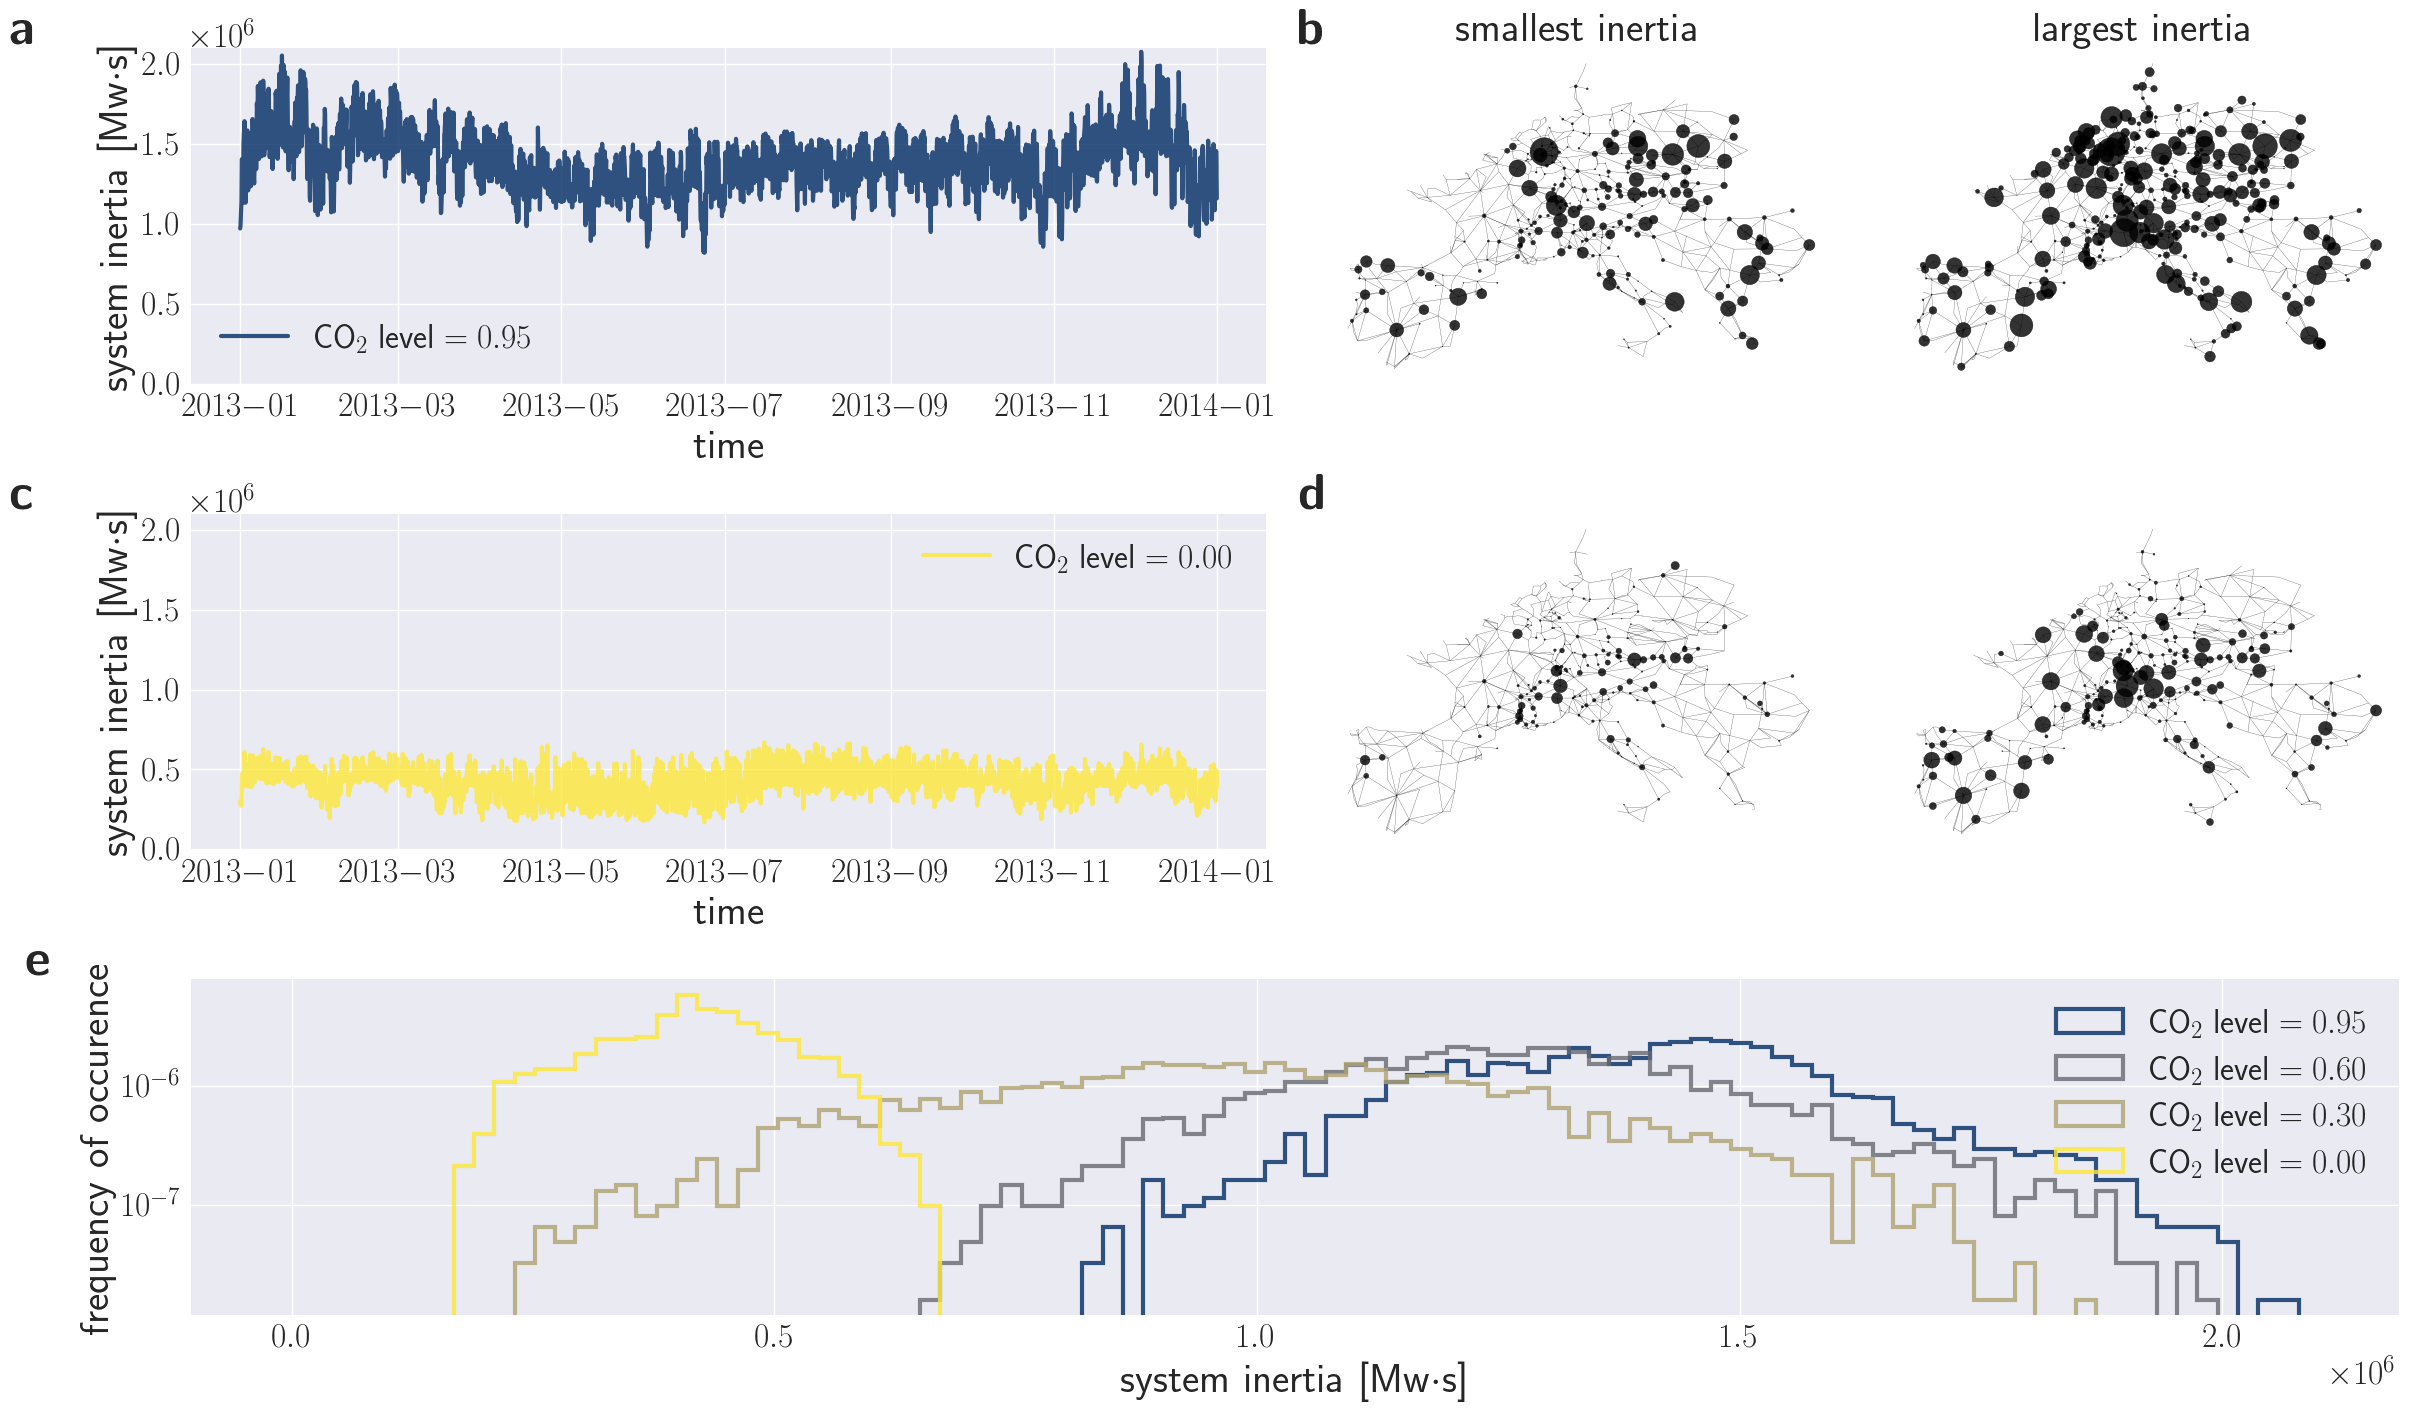

In [198]:
mpl.style.use('seaborn')

plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}'], [r'\textbf{e}']]

f = plt.figure(figsize=(24, 14), constrained_layout=True)

gs = GridSpec(3, 4, figure=f)

ax = f.add_subplot(gs[2, :])
ax2 = f.add_subplot(gs[0, :2])
ax3 = f.add_subplot(gs[1, :2])

ax21 = f.add_subplot(gs[0, 2])
ax22 = f.add_subplot(gs[0, 3])

ax31 = f.add_subplot(gs[1, 2])
ax32 = f.add_subplot(gs[1, 3])

axs = [[ax21, ax22], [ax31, ax32]]


# a )
cmap = plt.get_cmap('cividis_r')

bins = np.arange(0, 2.1e6, 2.1e4)

for count, level in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    ax.hist(inertia_time[ind]*6,
            bins=bins,
            histtype='step',
            label=r'$\text{CO}_2\text{ level} = %.2f$' % level,
            linewidth=3,
            color=cmap(ind/len(co2ls)),
            density=True,
            alpha=0.8)
ax.xaxis.offsetText.set_fontsize(24)

ax.legend(fontsize=24)
ax.tick_params(axis='both', which='both', labelsize=24)
ax.set_xlabel('system inertia [Mw$\cdot$s]',  fontsize=30)
ax.set_ylabel('frequency of occurence', fontsize=30)
ax.set_yscale('log')
# ax.set_ylim([0,3.5e5])

#####################################################

axes = [ax2, ax3]

for j, level in enumerate(target_levels):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    axes[j].plot(network.snapshots,
                 inertia_time[ind]*6,
                 color=cmap(ind/len(co2ls)),
                 lw=3,
                 alpha=0.8,
                 label=r'$\text{CO}_2\text{ level} = %.2f$' % level)
    axes[j].legend(fontsize=24)
    axes[j].tick_params(axis='both', which='both', labelsize=24)
    axes[j].set_ylabel('system inertia [Mw$\cdot$s]', fontsize=30)
    axes[j].set_xlabel('time', fontsize=30)
    axes[j].set_ylim([0, 2.1e6])
    axes[j].yaxis.offsetText.set_fontsize(24)


####################################################


titles = ['smallest inertia', 'largest inertia']

for j, level in enumerate(target_levels):

    for i in range(len(titles)):
        nx.draw_networkx_nodes(G,
                               pos,
                               ax=axs[j][i],
                               node_size=inertia_generation[j, i]/20,
                               alpha=0.8,
                               node_color='black')
        nx.draw_networkx_edges(G,
                               pos,
                               ax=axs[j][i],
                               alpha=0.8,
                               width=0.2)
        if j == 0:
            axs[j][i].set_title(titles[i], fontsize=30)
        axs[j][i].axis('off')


ax3.text(0 - 2.25*0.075, 1+0.05,
         labels[1][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)

ax2.text(0 - 2.25*0.075, 1+0.05,
         labels[0][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)

ax31.text(0 - 0.05, 1+0.05,
          labels[1][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax31.transAxes)
ax21.text(0 - 0.05, 1+0.05,
          labels[0][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax21.transAxes)


ax.text(0 - 0.075, 1+0.05,
        labels[2][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=ax.transAxes)


plt.savefig(save_path+'Figure2_total_system_inertia.pdf',bbox_inches = 'tight')


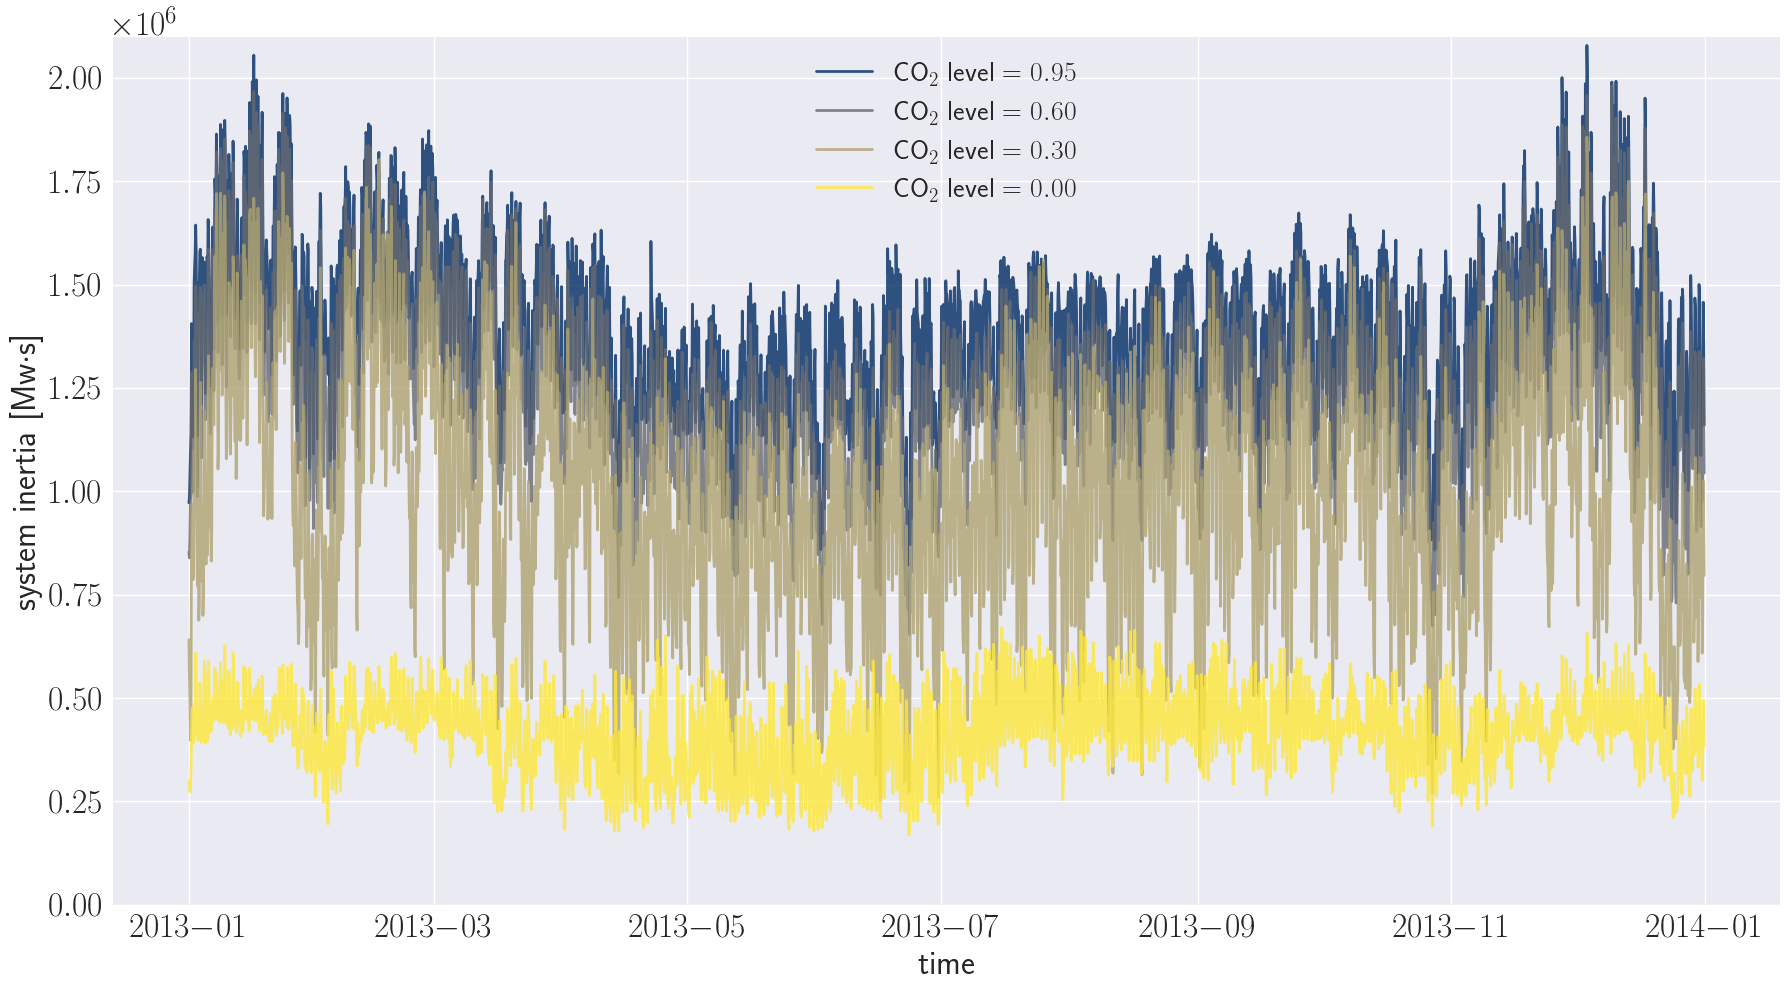

In [199]:

mpl.style.use('seaborn')
f, ax = plt.subplots(figsize=(18, 10))
cmap = plt.get_cmap('cividis_r')


for count, co2l in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    ax.plot(network.snapshots,
            inertia_time[ind]*6,
            color=cmap(ind/len(co2ls)),
            lw=2,
            alpha=0.8,
            label=r'$\text{CO}_2\text{ level} = %.2f$' % co2l)

ax.legend(fontsize=20)
ax.tick_params(axis='both', which='both', labelsize=24)
ax.set_ylabel('system inertia [Mw$\cdot$s]', fontsize=24)
ax.set_xlabel('time', fontsize=24)
ax.yaxis.offsetText.set_fontsize(24)
ax.set_ylim([0, 3.5e5*6])
plt.tight_layout()

plt.savefig(save_path+'SI_Europe_Total_system_inertia_over_time.pdf',bbox_inches = 'tight')


# Figure 4

In [200]:
mean_consumption_vector = np.load(
    path_to_pre_outage + 'mean_nodal_consumption_all_co2ls.npy')
dipole_vector = np.load(path_to_pre_outage +
                        'dipole_vector_time_series_all_co2ls.npy')
vec_norm = np.load(path_to_pre_outage + 'spi_time_series_all_co2ls.npy')


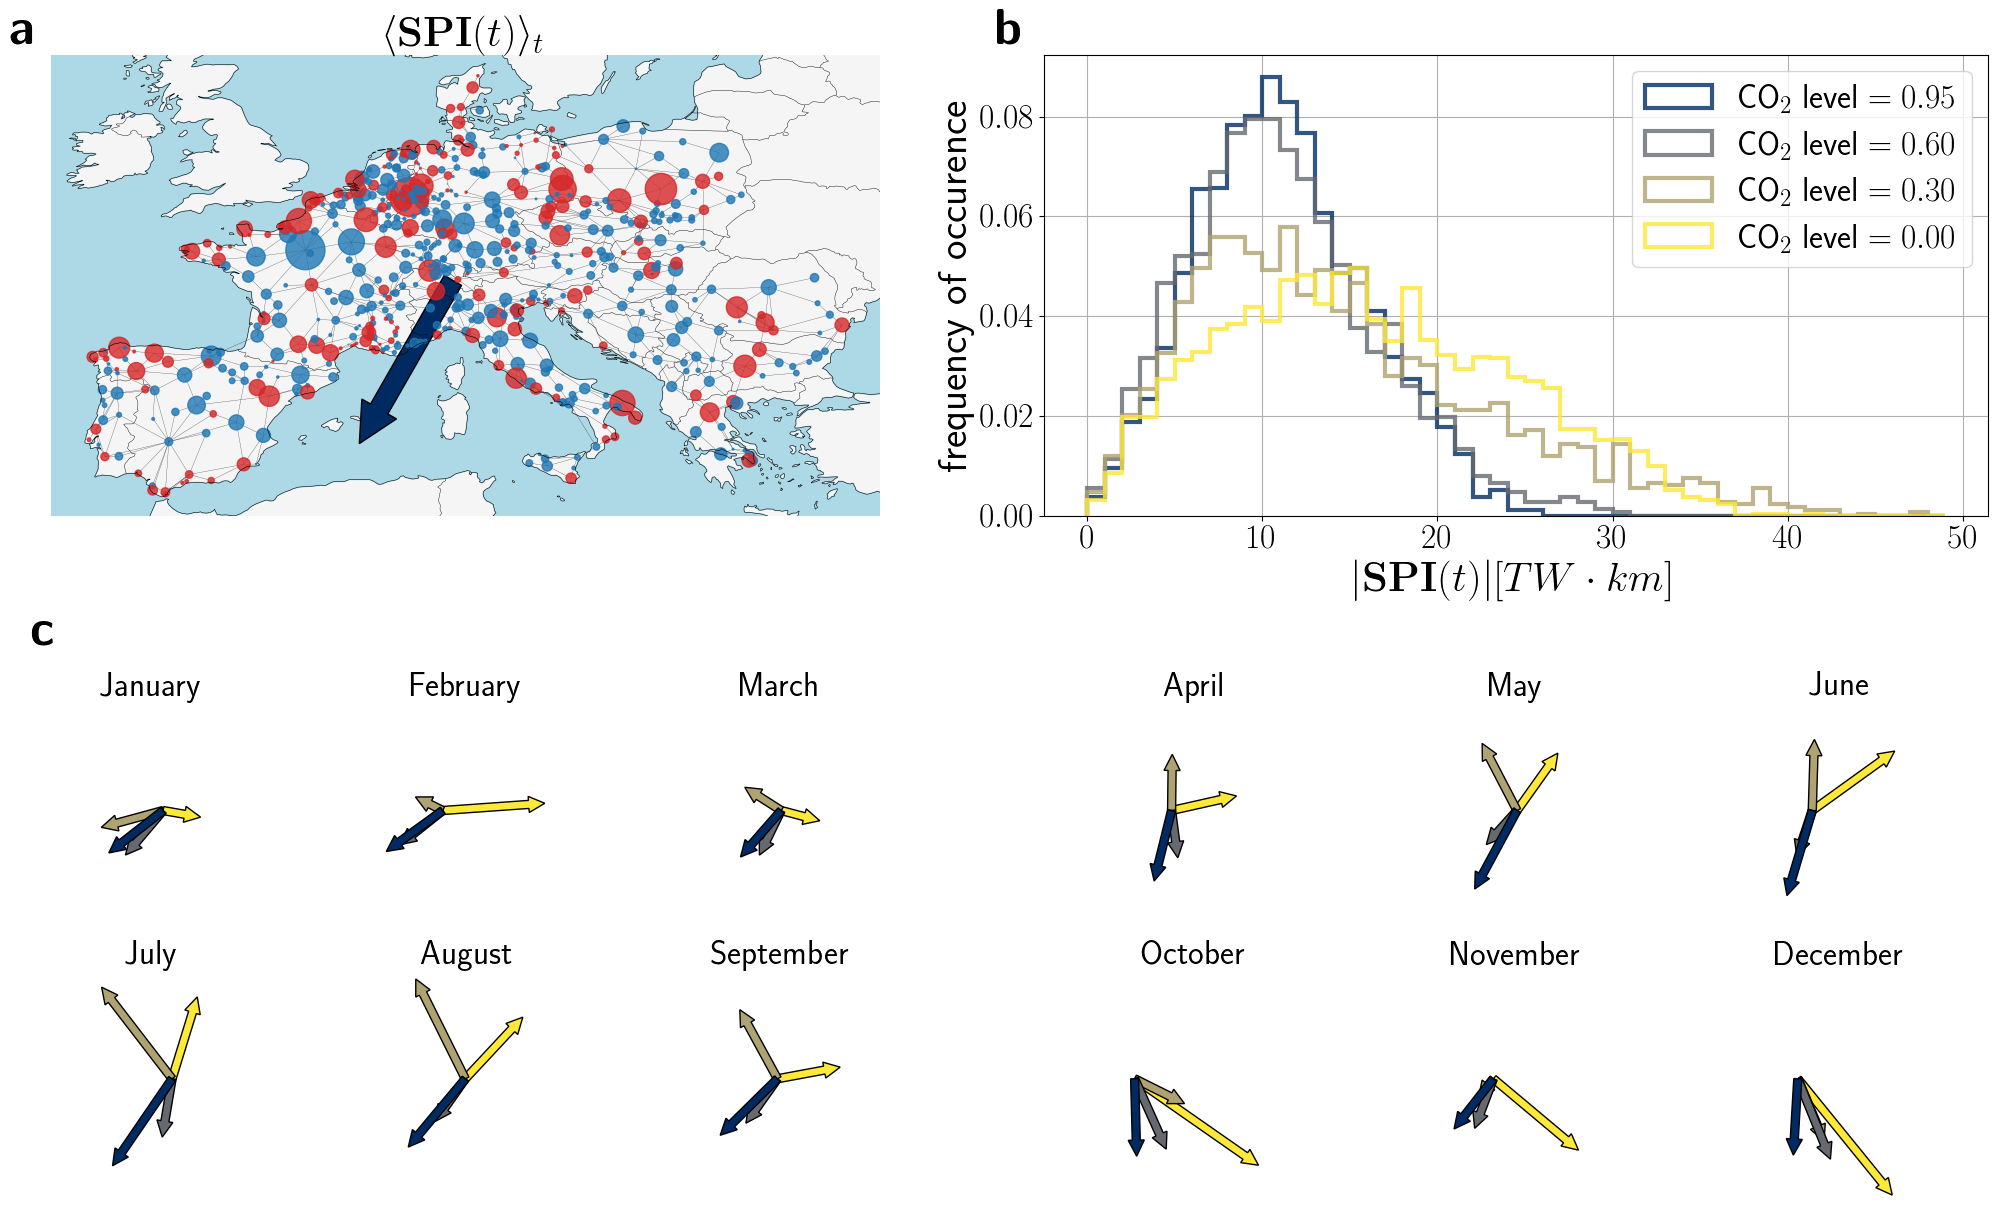

In [201]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}', r'\textbf{e}', r'\textbf{f}']]

f = plt.figure(figsize=(20, 12), constrained_layout=True)


gs = GridSpec(4, 6, figure=f)

ax = f.add_subplot(gs[:2, :3], projection=ccrs.PlateCarree())
ax2 = f.add_subplot(gs[:2, 3:])

axs = [f.add_subplot(gs[2, i], projection=ccrs.PlateCarree())
       for i in range(6)]
axs2 = [f.add_subplot(gs[3, i], projection=ccrs.PlateCarree())
        for i in range(6)]
axs_both = [axs, axs2]
###############################################

resolution = "50m"
color_geomap = {'ocean': 'lightblue', 'land': 'whitesmoke'}

ax.add_feature(cartopy.feature.LAND.with_scale(resolution),
               facecolor=color_geomap['land'])
ax.add_feature(cartopy.feature.OCEAN.with_scale(resolution),
               facecolor=color_geomap['ocean'])

ax.coastlines(linewidth=0.4, zorder=2, resolution=resolution)
border = cartopy.feature.BORDERS.with_scale(resolution)
ax.add_feature(border, linewidth=0.3)


cmap = plt.get_cmap('cividis_r')

position_vector = np.array([pos[n] for n in G.nodes()])
mean_pos = [np.mean(position_vector[:, 0]), np.mean(position_vector[:, 1])]


nx.draw_networkx_edges(G,
                       pos,
                       ax=ax,
                       alpha=0.8,
                       width=0.2)

scale_factor = 1e4

current_vec = np.mean(dipole_vector, axis=2)
vec = mean_consumption_vector

plot_co2ls = [0.95]

for i, level in enumerate(plot_co2ls):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    node_colours = ['tab:red' if vec[ind, i] <
                    0 else 'tab:blue' for i in range(len(G.nodes()))]

    nx.draw_networkx_nodes(G,
                           pos,
                           ax=ax,
                           node_size=np.abs(vec[ind])/10,
                           node_color=node_colours,
                           alpha=0.8)

    ax.arrow(mean_pos[0],
             mean_pos[1],
             current_vec[ind, 0]/scale_factor,
             current_vec[ind, 1]/scale_factor,
             head_width=2.0,
             width=1.0,
             head_length=2.0,
             #alpha  = .8,
             facecolor=cmap(ind/len(co2ls)))
    ax.axis('off')


# a )
#bins = np.arange(0,5e5,5000)
bins = np.arange(0, 5e1, 1)  # np.arange(0,0.08,0.001)#

for i, level in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]
    ax2.hist(vec_norm[ind],
             bins=bins,
             histtype='step',
             label=r'$\text{CO}_2\text{ level} = %.2f$' % level,
             linewidth=3,
             color=cmap(ind/len(co2ls)),
             density=True,
             alpha=0.8)
ax2.legend(fontsize=24)
ax2.tick_params(axis='both', which='both', labelsize=24)
ax2.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=30)
ax2.set_ylabel('frequency of occurence', fontsize=30)
ax2.grid(True)
ax2.yaxis.offsetText.set_fontsize(24)

#####################################################
old_ind = 0

for j in range(12):

    xcoord = int(j//6)
    ycoord = int(j % 6)

    new_ind = old_ind + \
        len(network.snapshots[network.snapshots.month == int(j+1)])

    current_vec = np.mean(dipole_vector[:, :, old_ind:new_ind], axis=2)

    for i, level in enumerate(selected_co2ls):
        ind = np.where(np.round(co2ls, 2) == level)[0][0]

        axs_both[xcoord][ycoord].arrow(mean_pos[0],
                                       mean_pos[1],
                                       current_vec[ind, 0]/scale_factor,
                                       current_vec[ind, 1]/scale_factor,
                                       head_width=2.0,
                                       width=1.0,
                                       head_length=2.0,
                                       #alpha  = .8,
                                       facecolor=cmap(ind/len(co2ls)))
    axs_both[xcoord][ycoord].axis('off')
    lims = axs_both[xcoord][ycoord].get_ylim()
    axs_both[xcoord][ycoord].set_ylim([31.707498915424157, 60.29928495567561])
    # print(lims)

    old_ind = new_ind

    # if xcoord == 0:
    #    pos1 = axs_both[xcoord][ycoord].get_position()
    #    pos2 = [pos1.x0, pos1.y0,pos1.width,pos1.height]
    #    axs_both[xcoord][ycoord].set_position(pos2)
####################################################

ax2.text(-0.05, 1+0.05,
         labels[0][1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)

ax.text(-0.05, 1+0.05,
        labels[0][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=ax.transAxes)

axs_both[0][0].text(-0.6, 1+0.3,
                    labels[1][0],
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_both[0][0].transAxes)

ax.set_title(r'$\langle \mathbf{SPI}(t)\rangle_t$', fontsize=30)


for j in range(12):
    xcoord = int(j//6)
    ycoord = int(j % 6)
    axs_both[xcoord][ycoord].set_title(network.snapshots[network.snapshots.month == j+1][0].month_name(),
                                       fontsize=24,
                                       pad=-500)

plt.savefig(save_path+'Figure3_inital_grid_situation.pdf',bbox_inches = 'tight')


# Figure 5

In [202]:
edge_likelihoods_primary = pickle.load(
    open(path_to_vis_results+f'edge_likelihoods_primary_all_co2ls.pickle', 'rb'))
edge_likelihoods_secondary = pickle.load(
    open(path_to_vis_results+f'edge_likelihoods_secondary_all_co2ls.pickle', 'rb'))


0.0032 3.38e-07


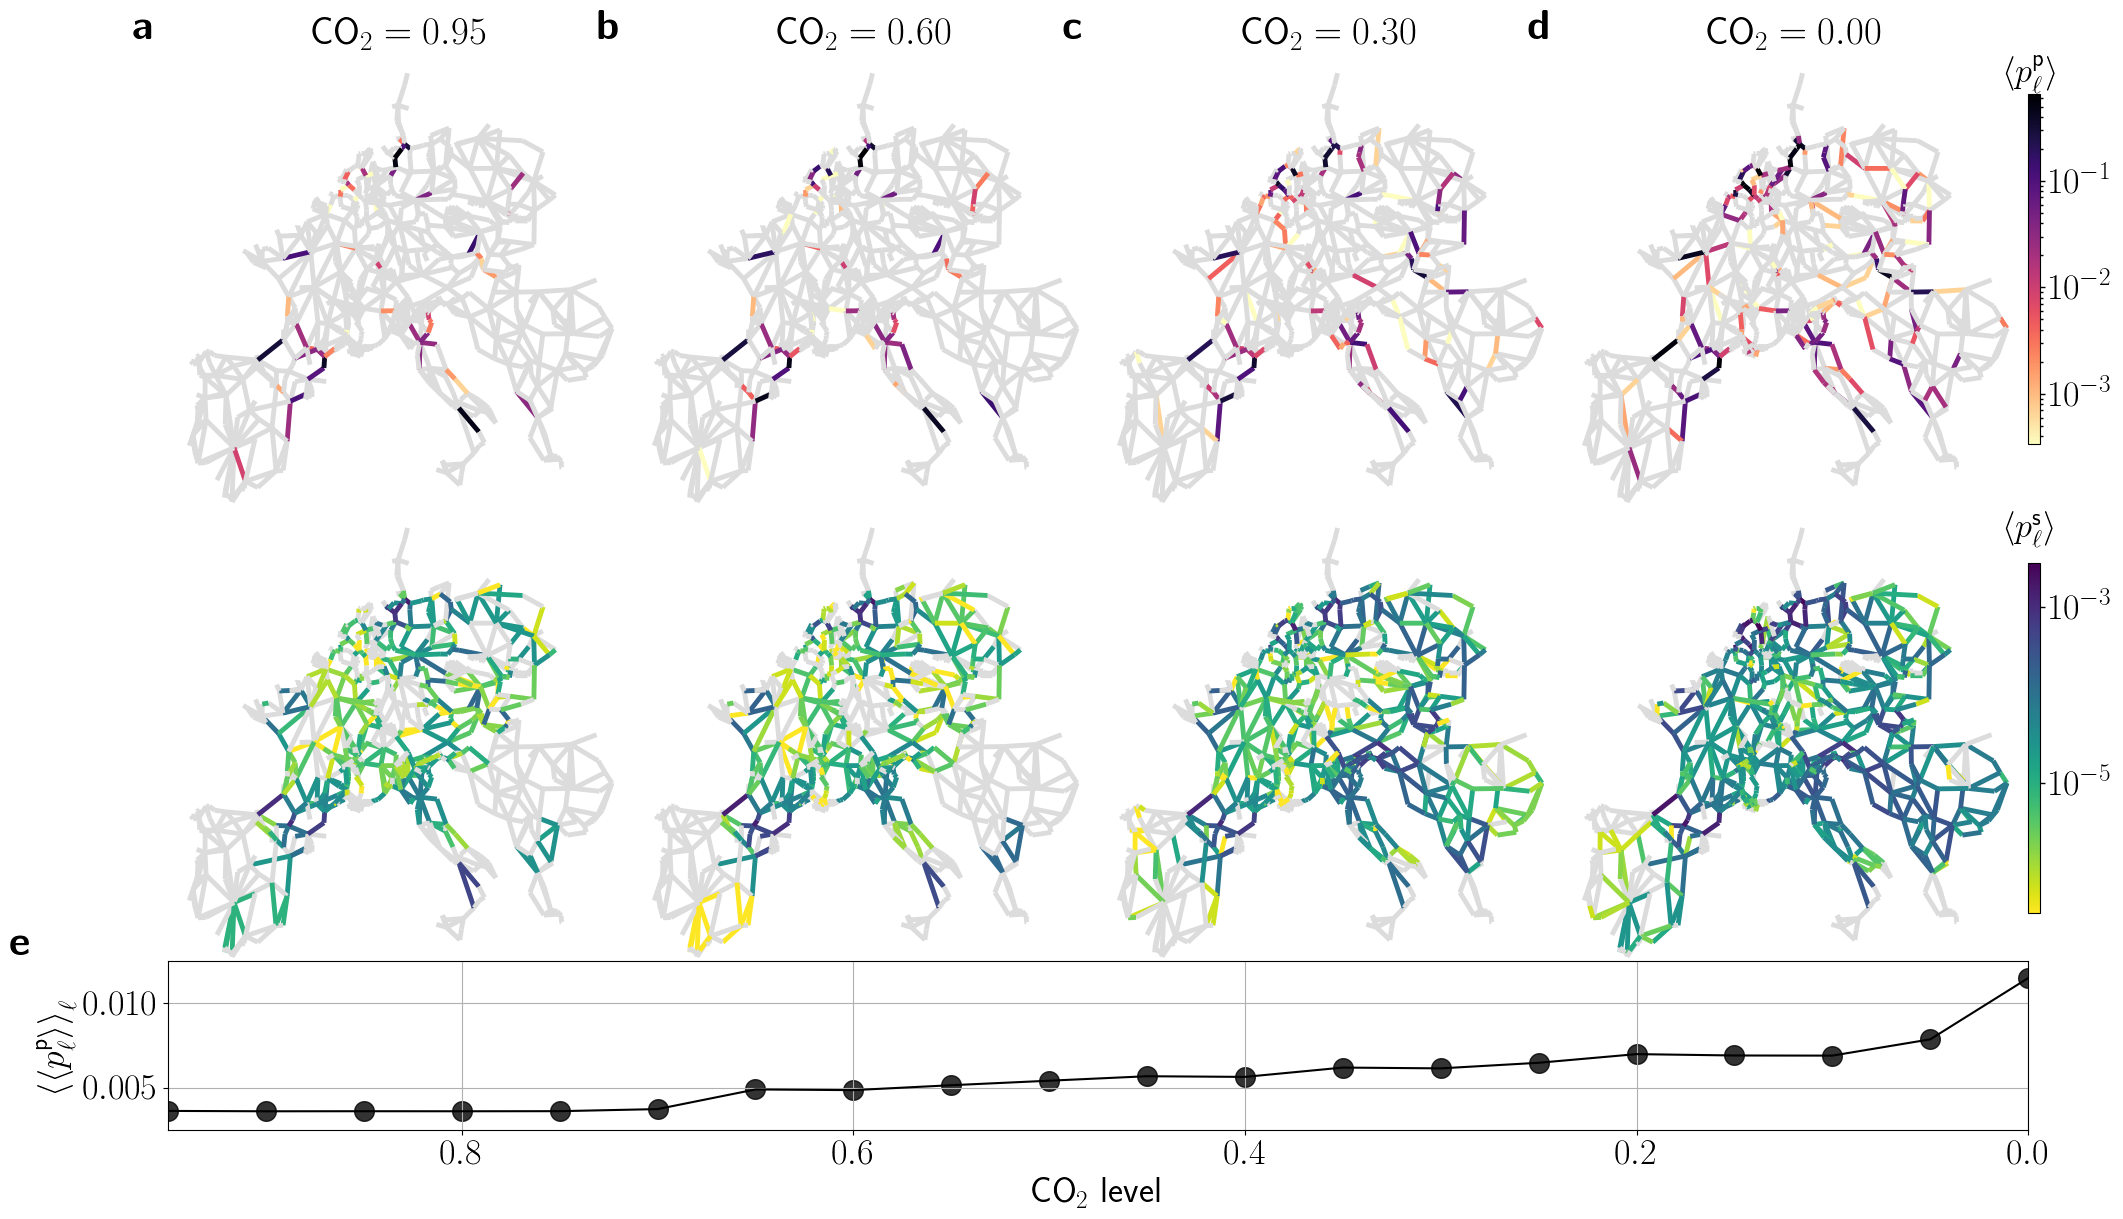

In [203]:

# setup figure
f = plt.figure(figsize=(24, 14))
gs = GridSpec(7, 4, figure=f)
axs = [f.add_subplot(gs[:3, i]) for i in range(4)]
axs2 = [f.add_subplot(gs[3:6, i]) for i in range(4)]
ax0 = f.add_subplot(gs[6, :])
f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro', 1.0)

# setup parameters
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []


for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in G.edges()]
    c_H_p_log = np.array([np.log10(x) if x > 1e-8 else -np.inf for x in c_H_p])

    vmax = 0.66
    vmin = 3.4e-4

    nodes = nx.draw_networkx_nodes(G,
                                pos=pos,
                                ax=axs[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(G,
                                pos=pos,
                                ax=axs[count],
                                edge_color=c_H_p_log,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs[count].axis('off')


cbar_ax = f.add_axes([0.9, 0.6, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=cbar_ax)
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs[3].text(0.95, 0.95,
            r'$\langle p_{\ell}^{\text{p}}\rangle$',
            fontsize=25,
            weight='bold',
            verticalalignment='center',
            transform=axs[3].transAxes)


cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in G.edges()]
    c_H_s_log = np.array([np.log10(x) if x > 1e-8 else -np.inf for x in c_H_s])

    vmax = 3.2e-3
    vmin = 3.38e-7
    vmaxvals.append(vmax)
    vminvals.append(vmin)

    nodes = nx.draw_networkx_nodes(G,
                                   pos=pos,
                                   ax=axs2[count],
                                   node_color='black',
                                   node_size=0)

    edges = nx.draw_networkx_edges(G,
                                   pos=pos,
                                   ax=axs2[count],
                                   edge_color=c_H_s_log,
                                   width=3.5,
                                   edge_cmap=cmap,
                                   edge_vmin=np.log10(vmin),
                                   edge_vmax=np.log10(vmax))

    axs2[count].axis('off')

    axs[count].set_title(r'$\text{CO}_2 = %.2f$' % co2l, fontsize=28)
    axs[count].text(0 - 0.075, 1+0.05,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs[count].transAxes)


cbar_ax = f.add_axes([0.9, 0.265, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=cbar_ax)
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs2[3].text(0.95, 0.95,
             r'$\langle p_{\ell}^{\text{s}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             transform=axs2[3].transAxes)
print(np.max(vmaxvals), np.min(vminvals))

#######################################################

levels = co2ls.round(2)[::-1]
mean_edge_likelihood_primary = [np.sum(list(edge_likelihoods_primary[level].values())) for level in levels]
mean_edge_likelihood_primary = np.array(mean_edge_likelihood_primary)/ len(G.edges())

ax0.scatter(co2ls[::-1],
            mean_edge_likelihood_primary,
            s=200,
            alpha=0.8,
            color='black')

ax0.plot(co2ls[::-1],
         mean_edge_likelihood_primary,
         color='black')

ax0.tick_params(axis='both', which='both', labelsize=26)


ax0.grid()
ax0.set_xlim([0, 0.95])
ax0.set_ylim([0.0025, 0.0125])
ax0.set_xlabel(r'$\text{CO}_2 \text{ level}$', fontsize=26)
ax0.set_ylabel(
    r'$\left\langle \langle p_{\ell}^{\text{p}}\rangle\right\rangle_{\ell}$', fontsize=26)

#pos1 = ax0.get_position()
#pos2 = [pos1.x0+0.045, pos1.y0,pos1.width*0.9,pos1.height*0.7]
# ax0.set_position(pos2)

ax0.invert_xaxis()

ax0.text(0 - 0.085,
         1+0.1,
         r'\textbf{e}',
         fontsize=30,
         weight='bold',
         verticalalignment='center',
         transform=ax0.transAxes)

#ax0.legend(fontsize = 16)

plt.savefig(save_path+'Fig4_likelihoods_Europe.pdf',bbox_inches = 'tight')


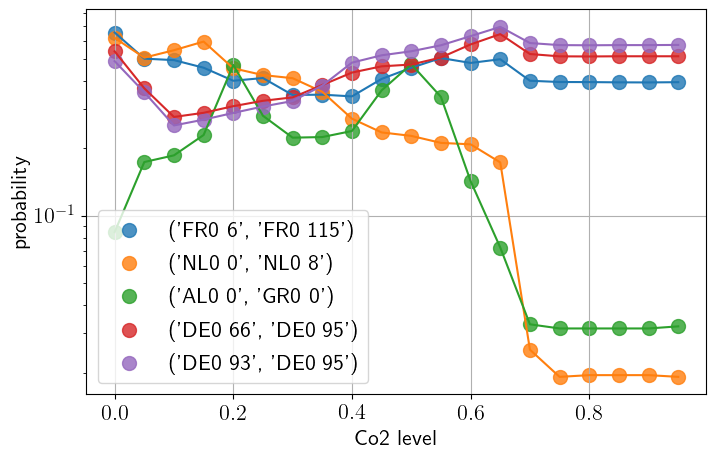

('DE0 93', 'DE0 95')

In [21]:
# indices of links with "interesting" primary failure likelihoods
indices = [601, 450, 0, 460, 473]
co2ls = np.arange(0.0, 0.99, 0.05)  # np.array([0.0,0.25,0.5,0.75])

f, ax = plt.subplots(figsize=(8, 5))

for index in indices:
    ax.scatter(co2ls,
               10**edge_likelihoods_primary[:, index],
               s=100,
               alpha=0.8,
               label=list(G.edges())[index])
    ax.plot(co2ls,
            10**edge_likelihoods_primary[:, index])

ax.set_yscale('log')
ax.tick_params(axis='both', which='both', labelsize=16)
ax.set_xlabel('Co2 level', fontsize=16)
ax.set_ylabel('probability',
              fontsize=16)
ax.grid()

ax.legend(fontsize=16)

plt.show()


list(G.edges())[index]


# Figure 6

In [ ]:
#TODO check and correct probabilities and value of risk. Correct normalization?

In [204]:
# Determine number of simulations,
# i.e., total number of initial failures over the simulated period of one year
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))
n_initial_failures = len(non_bridges)
n_time_stamps = network.snapshots.size
number_of_simulations = n_initial_failures*n_time_stamps

component_props = pd.read_hdf(
    '../results/split_visualization/split_comp_props_all_co2level_{}_based_w_hvdc_dist_9.h5'.format(criterion))

component_props.loc[:, 'rocof'] = 50* component_props.load_imbalance / (component_props.inertia_proxy*2*6)

ipykernel_launcher:168: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


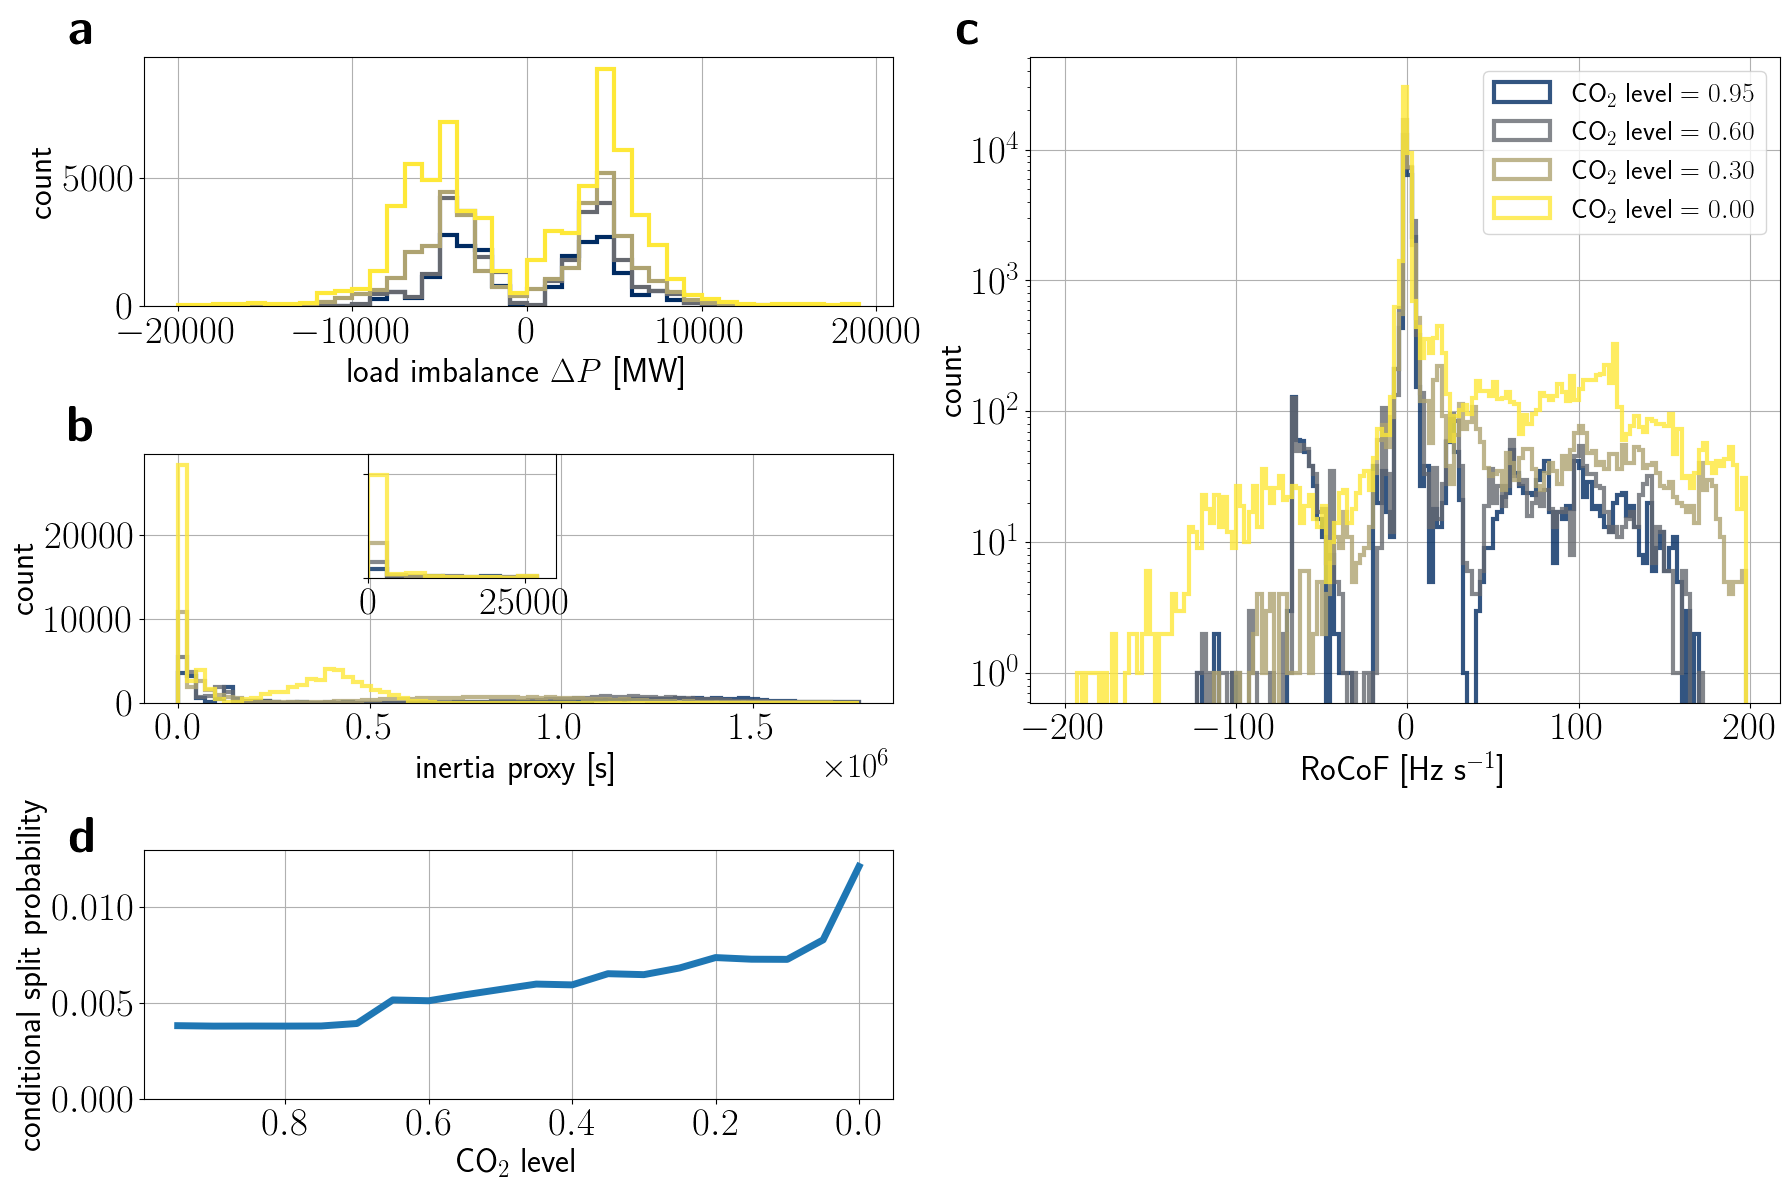

In [205]:
labels = [r'\textbf{a}', r'\textbf{b}',
          r'\textbf{c}', r'\textbf{d}', r'\textbf{e}']

mpl.style.use('default')

plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

co2ls = np.arange(0.0, 0.99, 0.05)

f = plt.figure(figsize=(18, 12), constrained_layout=True)

gs = GridSpec(3, 4, figure=f)


ax0 = f.add_subplot(gs[0, :2])
ax1 = f.add_subplot(gs[1, :2])

ax_ins = ax1.inset_axes([0.3, 0.5, 0.25, 0.5])
x1, x2, y1, y2 = 0.0, 6*5000, 0, 30000  # 0.0003

ax_ins.set_xlim(x1, x2)
ax_ins.set_ylim(y1, y2)

# ax_ins.set_xticklabels('')
ax_ins.set_yticklabels('')


ax2 = f.add_subplot(gs[:2, 2:])
ax31 = f.add_subplot(gs[2, :2])
#axs = [f.add_subplot(gs[2,i]) for i in range(4)]


snet_index = 0
cmap = plt.get_cmap('cividis_r')


for count, level in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    RoCoF = component_props[component_props.co2l==level].rocof
    load_imbalances = component_props[component_props.co2l==level].load_imbalance
    inertia_proxies = component_props[component_props.co2l==level].inertia_proxy


    maxval = int(2e4)  # 3.5e4
    bins = np.arange(-maxval, maxval, 1000)
    # ax[count].hist(RoCoF.flatten(),bins = bins, label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l)#i//2,i%2
    if len(load_imbalances):
        ax0.hist(load_imbalances,
                 bins=bins,
                 histtype='step',
                 label=r'$\text{CO}_2\text{ level} = %.2f$' % level,
                 linewidth=3,
                 color=cmap(ind/len(co2ls)),
                 density=False)

        maxval = int(1.8e6)  # 4e5
        bins = np.arange(0, maxval, 24000)
        #bins = np.arange(0,5e3,500)
        ax1.hist(np.array(inertia_proxies)*6,
                 bins=bins,
                 histtype='step',
                 label=r'$\text{CO}_2\text{ level} = %.2f$' % level,
                 linewidth=3,
                 color=cmap(ind/len(co2ls)),
                 alpha=0.8,
                 density=False)

        bins = np.arange(0, 3e4, 3000)
        ax_ins.hist(np.array(inertia_proxies)*6,
                    bins=bins,
                    histtype='step',
                    linewidth=3,
                    color=cmap(ind/len(co2ls)),
                    alpha=0.8,
                    density=False)

        maxval = int(2e2)  # 4e5
        bins = np.arange(-maxval, maxval, 2.5)
        #bins = np.arange(0,5e3,500)
        ax2.hist(RoCoF,
                 bins=bins,
                 histtype='step',
                 label=r'$\text{CO}_2\text{ level} = %.2f$' % level,
                 linewidth=3,
                 color=cmap(ind/len(co2ls)),
                 alpha=0.8,
                 density=False)


ax2.grid(True)
ax1.grid(True)
ax0.grid(True)
ax_ins.grid(True)

ax0.set_xlabel(r'load imbalance $\Delta P$ [MW]',
               fontsize=24)
ax1.set_xlabel(r'inertia proxy [s]',
               fontsize=24)


#from matplotlib import ticker
#formatter = ticker.ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# ax0.yaxis.set_major_formatter(formatter)
# ax0.ticklabel_format(useOffset=True)

ax_ins.tick_params(axis='both', which='both', labelsize=28)

ax0.tick_params(axis='both', which='both', labelsize=28)
ax0.set_ylabel(r'count', fontsize=24)

# ax0.legend(fontsize=20)
ax1.tick_params(axis='both', which='both', labelsize=28)
# ax1.legend(fontsize=20)
ax1.yaxis.offsetText.set_fontsize(24)
ax1.xaxis.offsetText.set_fontsize(24)
ax1.set_ylabel(r'count', fontsize=24)


nof_splits = component_props.groupby(by=['co2l','time_stamp']).number_of_split.nunique().sum(level='co2l')
ax31.plot(co2ls, nof_splits/number_of_simulations, lw=5)
ax31.invert_xaxis()
ax31.grid(True)
ax31.set_ylim([0.0, 0.013])
ax31.tick_params(axis='both', which='both', labelsize=28)
ax31.set_xlabel(r'$\text{CO}_2\text{ level}$', fontsize=24)
ax31.set_ylabel(r'conditional split probability',
                fontsize=24)
################################################

ax2.tick_params(axis='both', which='both', labelsize=28)
ax2.legend(fontsize=20)
ax2.set_xlabel(r'RoCoF [Hz s$^{-1}$]', fontsize=24)
ax2.set_ylabel(r'count', fontsize=24)

ax2.set_yscale('log')


ax0.text(0 - 0.1, 1+0.1,
         labels[0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax0.transAxes)

ax1.text(0 - 0.1, 1+0.1,
         labels[1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax1.transAxes)

ax2.text(0 - 0.1, 1+0.04,
         labels[2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)
ax31.text(0 - 0.1, 1+0.04,
          labels[3],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax31.transAxes)
plt.tight_layout()

plt.savefig(save_path+'Fig5_Rocof_and_inertia_proxies.pdf',
            bbox_inches='tight')



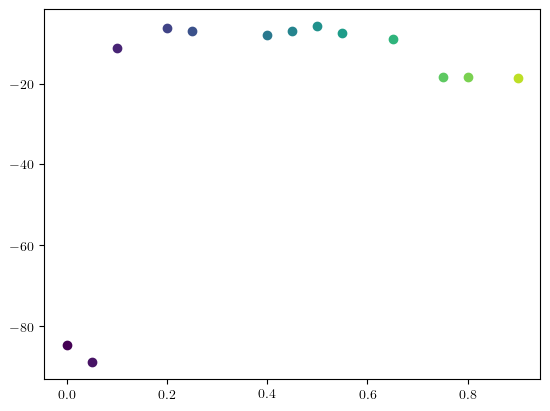

In [97]:
for co2l in co2ls:
    quant = component_props[(component_props.co2l==co2l)].rocof
    quant = quant.quantile(0.02)
    if quant==-np.inf:
        plt.plot(co2l, -500, 'o', c=plt.get_cmap('viridis')(co2l))
    else:
        plt.plot(co2l, quant, 'o', c=plt.get_cmap('viridis')(co2l))

In [77]:

nof_comps = component_props.groupby(by=['co2l','time_stamp', 'number_of_split']).count().inertia_proxy
print('2 comps [%]:', 100*(nof_comps==2).sum()/nof_comps.shape[0])
print('3 comps [%]:', 100*(nof_comps==3).sum()/nof_comps.shape[0])
print('4 comps [%]:', 100*(nof_comps==4).sum()/nof_comps.shape[0])

2 comps [%]: 96.0892114614047
3 comps [%]: 3.8082709609132834
4 comps [%]: 0.0834656384667725


# Figure 7

In [ ]:
#TODO check and correct probabilities and value of risk. Correct normalization?

In [206]:
indicator_vectors = np.load(
    '../results/split_visualization/ind_vec_all_co2level_{}_based_w_hvdc_dist_9.npy'.format(criterion))

In [207]:
#TODO : Check if VaR calculation is correct

# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
cluster_props = component_props.groupby(
    ['cluster_label', 'co2l']).size().to_frame('counts')
cluster_props.loc[:, 'likelihood'] = cluster_props.counts.div(
    number_of_simulations)

# Risk values
cluster_props.loc[:, 'upper_quantile_rocof'] = component_props.groupby(
     ['cluster_label', 'co2l']).rocof.quantile(0.9, interpolation='lower').abs()
cluster_props.loc[:, 'lower_quantile_rocof'] = component_props.groupby(
     ['cluster_label', 'co2l']).rocof.quantile(0.1, interpolation='higher').abs()



# this DataFrame has a Multiindex (cluster_label, co2l)
cluster_props.head()


counts  likelihood  upper_quantile_rocof  \
cluster_label co2l                                             
-1.0          0.00     159    0.000057             26.267050   
              0.05     106    0.000038             38.851700   
              0.10      67    0.000024             74.665860   
              0.15      37    0.000013             12.578456   
              0.20      30    0.000011             10.798833   

                    lower_quantile_rocof  
cluster_label co2l                        
-1.0          0.00              2.630731  
              0.05              2.698008  
              0.10              1.536683  
              0.15              3.794199  
              0.20              1.541353

In [208]:
selected_cluster = cluster_props.lower_quantile_rocof.max(level='cluster_label').to_frame('max_risk')
selected_cluster.loc[:, 'max_probability'] = cluster_props.likelihood.max(level='cluster_label')
selected_cluster = selected_cluster[(selected_cluster.max_risk>1)].sort_values('max_probability').iloc[-8:]
selected_cluster

,max_risk,max_probability
cluster_label,,
201.0,65.329329,0.000512
50.0,9.295064,0.000527
7.0,4.331211,0.000764
115.0,22.597239,0.000799
263.0,39.266194,0.000941
19.0,2.648915,0.002081
61.0,79.465931,0.003208
32.0,inf,0.003329


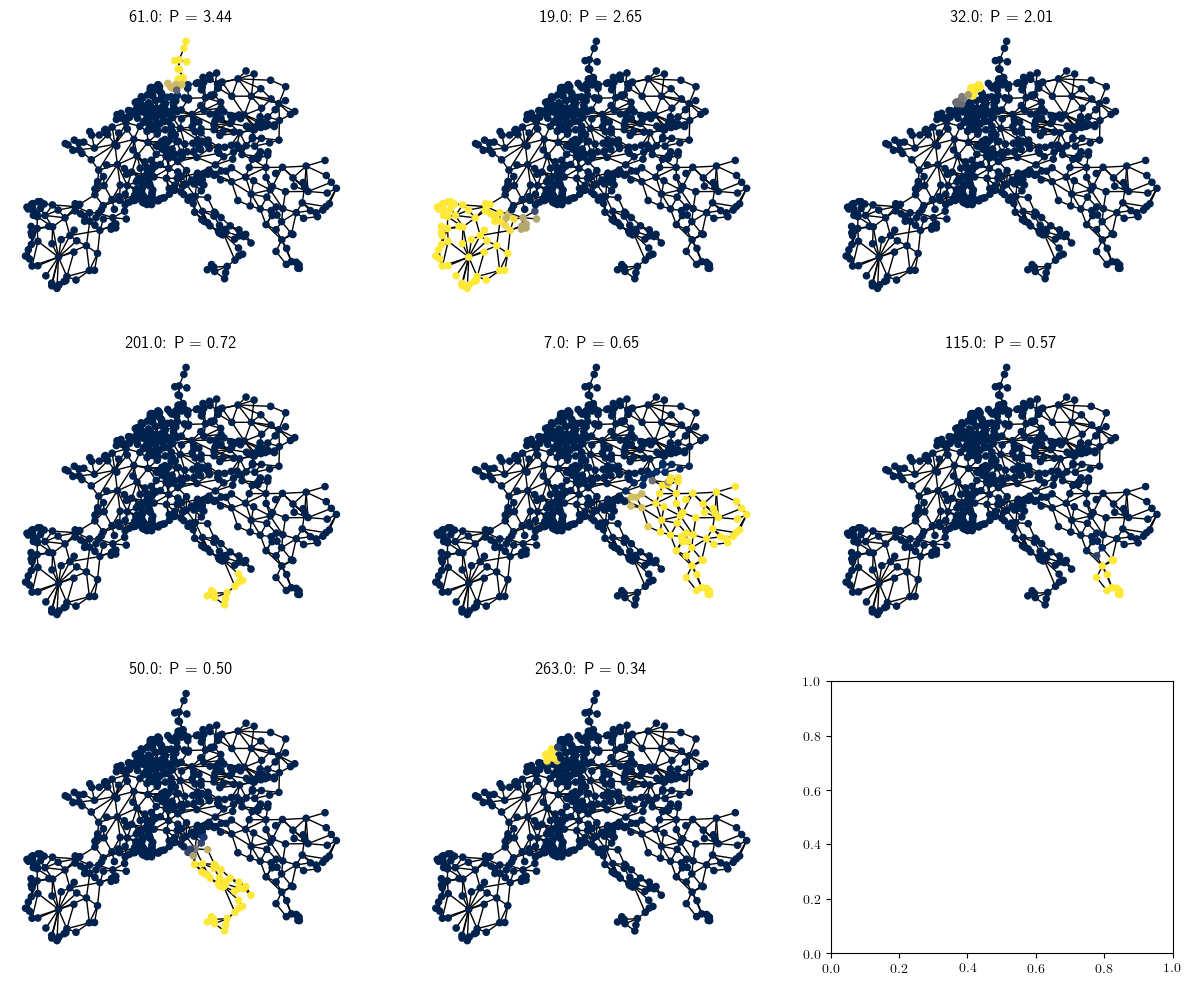

In [243]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_selected_cluster = selected_cluster.shape[0]
n_cols = 3  # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors[component_props.cluster_label.isin(
    selected_cluster.index)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(
    selected_cluster.index)].cluster_label
selected_cluster_props = cluster_props.loc[:, [
    'likelihood', 'counts']].groupby('cluster_label').sum()
selected_cluster_props = selected_cluster_props[selected_cluster_props.index.isin(
    selected_cluster_labels)]

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     selected_cluster_props,
                                     G)


0 201.0
201.0
1 50.0
50.0
2 7.0
7.0
3 115.0
115.0
4 263.0
263.0
5 19.0
19.0
6 61.0
61.0
7 32.0
32.0


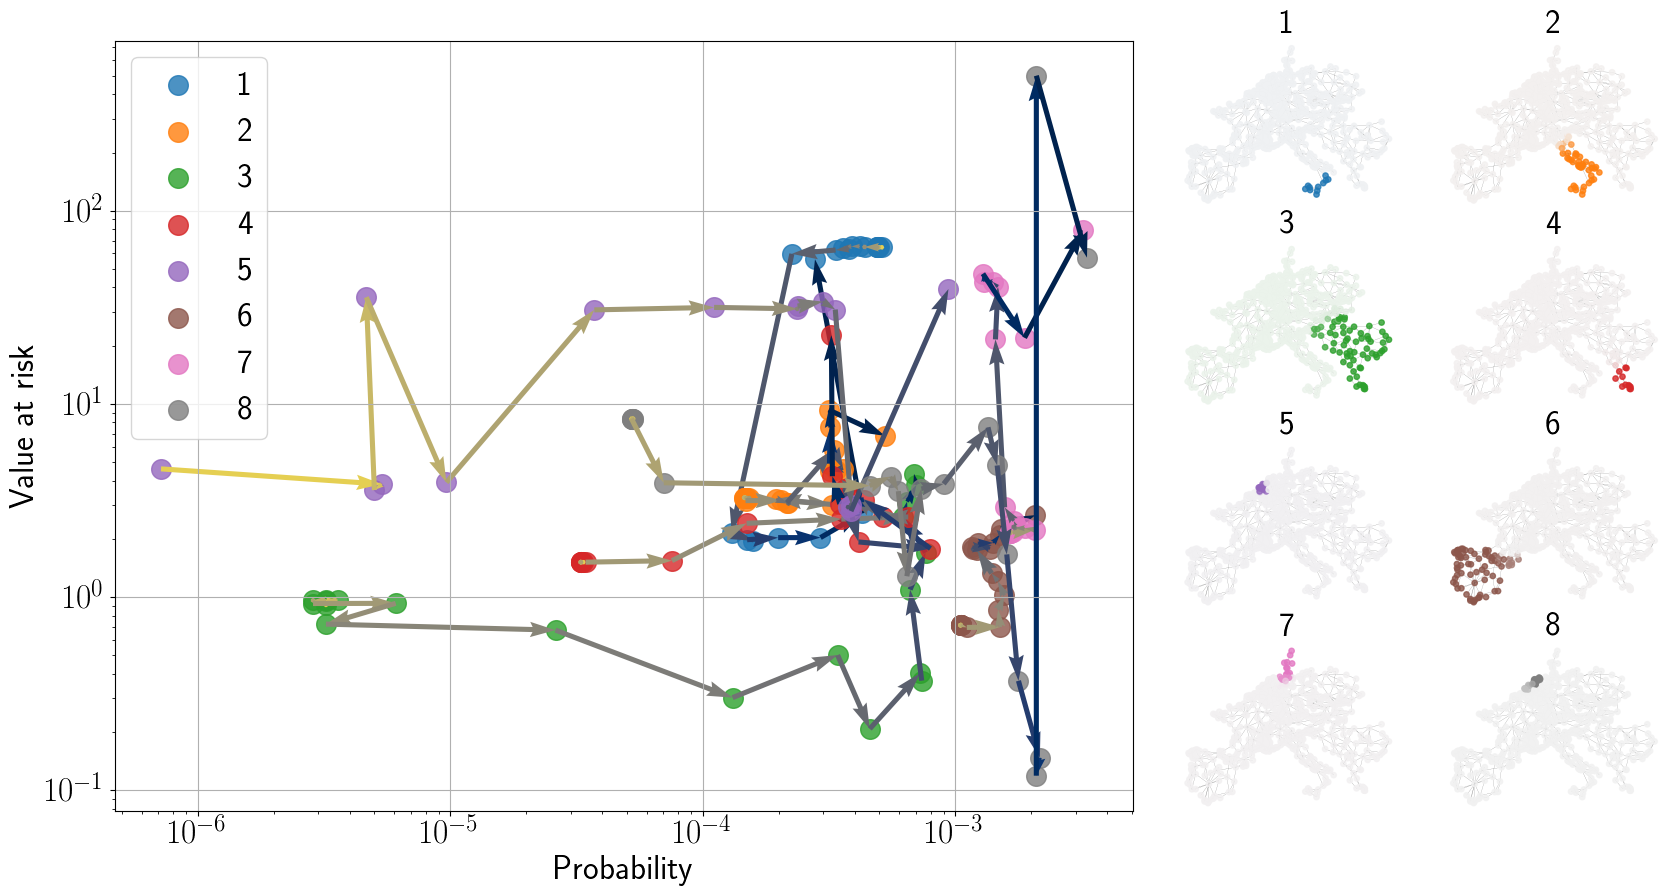

In [244]:


# Setup figure
from palettable.colorbrewer.sequential import YlGnBu_9
from palettable.cartocolors.sequential import agSunset_7
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
f = plt.figure(figsize=(20, 10))
gs = GridSpec(4, 6, figure=f)

# Prepare axes for map plots.
# Only plot 8 most important cluster
axs = []
for i in range(4):
    axs.append([])
    for j in range(2):
        axs[i].append(f.add_subplot(gs[i, j+4]))
        axs[i][j].axis('off')

# Prepare axis for risk-probability plot
ax = f.add_subplot(gs[:, :4])
ax.grid(True)


### Probability-risk plot ###


cmap = YlGnBu_9.mpl_colormap  # agSunset_7.mpl_colormap #Solar_3.mpl_colormap
# [cmap((i+1)/(len(selected_cluster)+1)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')
cluster_colors = sns.color_palette('tab10', selected_cluster.shape[0])

co2_cmap = plt.get_cmap('cividis')
co2_colors = [co2_cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]

start_index = 6


for i, cluster in enumerate(selected_cluster.index):
    print(i, cluster)

    # Extract likelihood-risk points for different co2 levels
    points = np.array([cluster_props.loc[cluster].likelihood,
                       cluster_props.loc[cluster].lower_quantile_rocof.replace(np.inf, 500)]).T  # ['mean_neg_rocof']]).T#

    # Plot likelihood-risk points
    ax.scatter(points[:, 0],
               points[:, 1],
               s=200,
               color=cluster_colors[i],
               label=str(i+1),  # cluster,
               alpha=0.8)

    # yerr = np.array([cluster_props.loc[indices[i]]['upper_quantile_neg_rocof'],
    #                 cluster_props.loc[indices[i]]['lower_quantile_neg_rocof']])
    # print(yerr)
    # ax.errorbar(points[:, 0],
    #             points[:, 1],
    #             yerr = yerr,
    #             fmt = 'o',
    #            color = colors_points[i],
    #           capsize = 10)

    # Plot arrows between likelihood-risk points (indicating step-wise co2 reduction)
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
              (points[:-1, 0]-points[1:, 0])[::-1],
              (points[:-1, 1]-points[1:, 1])[::-1],
              angles='xy',
              scale_units='xy',
              scale=1,
              width=0.005,  # 0.004,
              color=co2_colors)

    print(cluster)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Probability', fontsize=24)
ax.set_ylabel('Value at risk', fontsize=24)
ax.tick_params(axis='both', which='both', labelsize=24)
ax.legend(fontsize=24)


### Plots maps with split cluster ####

selected_ind_vectors = indicator_vectors[component_props.cluster_label.isin(
    selected_cluster.index)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(
    selected_cluster.index)].cluster_label
node_positions = nx.get_node_attributes(G, 'pos')


for i, label in enumerate(selected_cluster.index):
    xcoord = int(i//2)
    ycoord = int(i % 2)
    cmap2 = sns.light_palette(
        cmap((i+1)/(selected_cluster.shape[0]+1)), as_cmap=True)

    mean_ind_vector = np.array(
        [selected_ind_vectors[selected_cluster_labels.values == label].mean(0)])

    nx.draw(G,
            pos=node_positions,
            node_size=15,
            width=0.1,
            alpha=0.8,
            ax=axs[xcoord][ycoord],
            node_color=mean_ind_vector,
            cmap=sns.light_palette(cluster_colors[i], as_cmap=True),
            vmin=0,
            vmax=1)

    axs[xcoord][ycoord].set_title('{}'.format(str(i+1)),  # label
                                  fontsize=24)


plt.savefig(save_path + 'Figure6_risk_probability_plot.pdf', dpi=200, bbox_inches='tight')


In [242]:
component_props[(component_props.cluster_label==263)&(component_props.co2l==0.60)]

,co2l,time_stamp,number_of_split,inertia_proxy,load_imbalance,available_flexible_generation,causing_link,cluster_label,rocof
159914,0.6,31_01_2013_00,40.0,492.0,4278.905931,NaN,1035.0,263.0,36.237347
160429,0.6,05_02_2013_00,37.0,492.0,4389.940431,NaN,1035.0,263.0,37.177680
160612,0.6,07_02_2013_03,24.0,3579.0,4148.779873,NaN,1035.0,263.0,4.830004
163796,0.6,22_03_2013_06,33.0,4229.0,3594.586195,NaN,1035.0,263.0,3.541604
164936,0.6,04_04_2013_00,28.0,3579.0,3693.514699,NaN,1035.0,263.0,4.299985
168166,0.6,13_05_2013_21,25.0,1780.0,4202.506615,NaN,1035.0,263.0,9.837328
169998,0.6,07_06_2013_18,26.0,4229.0,3623.391114,NaN,1035.0,263.0,3.569984
170550,0.6,15_06_2013_18,32.0,492.0,4040.083401,NaN,1035.0,263.0,34.214798
177053,0.6,16_09_2013_06,27.0,4229.0,3995.437958,NaN,1035.0,263.0,3.936547
177156,0.6,17_09_2013_03,25.0,3579.0,3836.719184,NaN,1035.0,263.0,4.466703


0 201.0
1 50.0
2 7.0
3 115.0
4 263.0
5 19.0
6 61.0
7 32.0


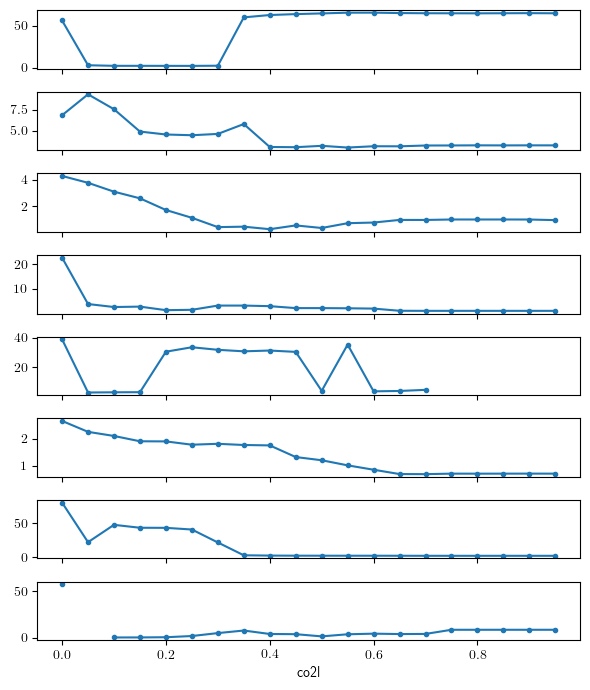

In [246]:
fig, ax = plt.subplots(8,1, figsize=(6,7), sharex=True)

for i,cluster in enumerate(selected_cluster.index):
    data = cluster_props.xs(round(cluster,0), level='cluster_label').lower_quantile_rocof.replace(np.inf, np.nan)
    data.plot(ax=ax[i], style='.-')
    print(i, cluster)
    
plt.tight_layout()

# Figure 8

In [ ]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.0, 0.40, 0.80]

f, ax = plt.subplots(3, 2, figsize=(24, 24), subplot_kw={
                     "projection": ccrs.PlateCarree()})
vmax = 3.2e2
months = [1, 7]

labels = [[r'\textbf{a}', r'\textbf{b}', r'\textbf{c}'],
          [r'\textbf{c}', '', r'\textbf{d}', '', '']]

for i, ind in enumerate(target_levels):

    n = pypsa.Network()
    n.import_from_netcdf(path_to_pypsa_network +
                         f'elec_s_800_ec_lv1.0_Co2L{ind}-3H.nc')

    for j, month in enumerate(months):

        ax[i, j].set_ylim([0, vmax])
        current_snapshots = n.snapshots[n.snapshots.month == month]

        n.plot(bus_sizes=n.generators_t.p.loc[current_snapshots].sum().groupby([n.generators["bus"], n.generators["carrier"]]).sum()/2e6,
               line_colors='black',
               link_colors='black',
               link_widths=0.5,
               line_widths=0.5,
               ax=ax[i, j])

        if i == 0:
            ax[i, j].set_title(current_snapshots.month_name()[0], fontsize=24)
        if j == 0:
            ax[i, j].text(0 - 0.1, 1+0.05,
                          labels[j][i],
                          fontsize=36,
                          weight='bold',
                          verticalalignment='center',
                          transform=ax[i, j].transAxes)

            ax[i, j].text(0 - 0.4, 0.5,
                          r'CO$_2$ level = '+str(ind),
                          fontsize=24,
                          verticalalignment='center',
                          transform=ax[i, j].transAxes)
plt.tight_layout()
# plt.savefig(save_path+'Figures/SI_Generation_mix_versus_co2level.pdf',bbox_inches='tight')
plt.show()


# Figure 10

In [24]:
# calculate line flows

bins = np.arange(0, 1.0, 0.02)

co2ls = np.arange(0.0, 1.0, 0.2)

hist_vals = np.zeros((len(co2ls), len(bins)-1))


for count, co2l in enumerate(selected_co2ls):

    path_to_pypsa_network = path + \
        'Data/system_split/European_Networks/New_networks_CO2_levels/'
    results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

    network = pypsa.Network()
    currentlevel = np.round(co2l, 2)
    network.import_from_netcdf(
        path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{currentlevel}-3H.nc')

    snet_index = 0

    G = utils.build_networkx_graph(network, snet_index=snet_index)

    indices = nx.get_edge_attributes(G, 'line_index')
    line_limits = nx.get_edge_attributes(G, 's_nom')

    for e, index_list in tqdm(indices.items()):
        loadings = np.abs(
            network.lines_t.p0.T.loc[index_list[0]]/line_limits[e])
        current_hist = np.histogram(loadings, bins)[0]
        hist_vals[count] += current_hist
    # for e, index_list in indices.items()}


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
100%|██████████| 1008/1008 [00:00<00:00, 1455.03it/s]
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as

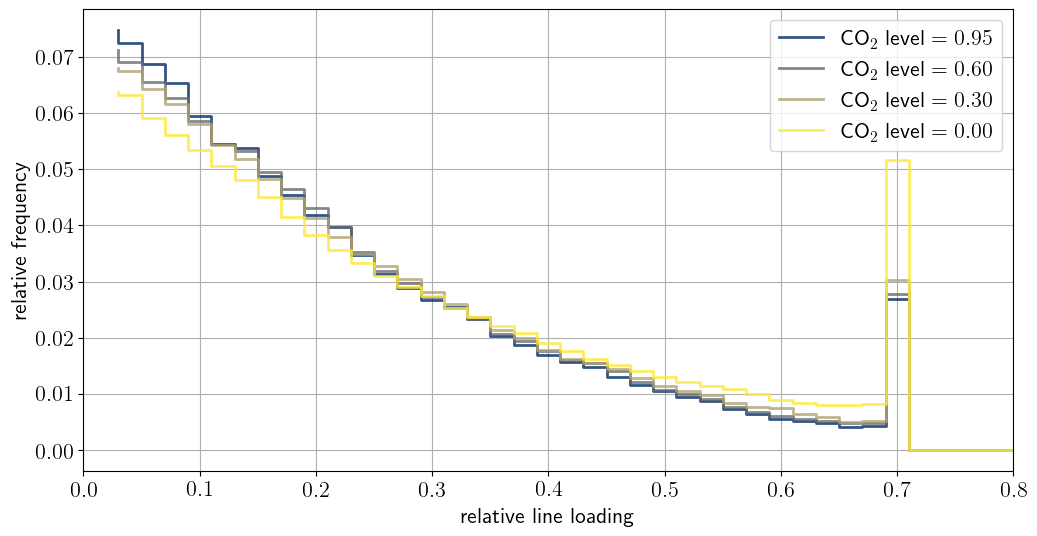

In [25]:
xpoints = (bins + (bins[1]-bins[0])/2)[1:]

co2ls = np.arange(0.0, 1.0, 0.05)

f, ax = plt.subplots(figsize=(12, 6))

for count, co2l in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    ax.step(xpoints,
            hist_vals[3-count]/np.sum(hist_vals[3-count]),
            label=r'$\text{CO}_2\text{ level} = %.2f$' % co2l,
            linewidth=2,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
ax.legend(fontsize=16)
#width = (bins[1]-bins[0])/2,
# label = 'data')
ax.set_xlim([0, 0.8])
ax.tick_params(axis='both', which='both', labelsize=16)
ax.set_xlabel(r'relative line loading', fontsize=16)
ax.set_ylabel(r'relative frequency', fontsize=16)
ax.grid(True)
# ax.set_yscale('log')
# ax.set_ylim([4e-3,1e-1])
#plt.savefig(save_path+'Figures/SI_line_utilization_versus_CO2.pdf',bbox_inches = 'tight')

plt.show()


# Synthetic inertia

In [182]:
path_to_pypsa_network = path + \
    'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
cluster_results_path = '/media/jkruse/Projects/system_splits/power-system-split/results/'

criterion = 'nodes'  # or 'load'
snet_index = 0  # only AC grid of CE
co2ls = [0.0, 0.95]


In [179]:
# the graph G should be independent of co2l right? so that we can load it out of the loop!?
network = pypsa.Network()
# +year+'/elec_s_306_ec_lv1.0_1H.nc')#
network.import_from_netcdf(path_to_pypsa_network +
                           'elec_s_800_ec_lv1.0_Co2L0.0-3H.nc')
G = utils.build_networkx_graph(network, snet_index=snet_index)


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [181]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))
n_initial_failures = len(non_bridges)
n_subset_solutions = -1
if n_subset_solutions == -1:
    n_time_stamps = network.snapshots.size
else:
    n_time_stamps = n_subset_solutions

number_of_simulations = n_initial_failures*n_time_stamps


In [183]:
component_props = pd.DataFrame(columns=[
                               'co2l', 'time_stamp', 'number_of_split', 'inertia_proxy', 'load_imbalance', 'causing_link'])
indicator_vectors = np.empty((0, len(G)), dtype='int')

for co2l in co2ls[:1]:
    print('\n', 'CO2 level ', co2l)
    level = np.round(co2l, 2)
    level_string = f'Co2L{level}'
    print(level_string)
    splitting_cascades = pickle.load(
        open(results_path+f'system_splits_Co2L{level}.pickle', 'rb'))
    fname = f'Europe_Co2L{level}_split_evaluation_' + \
        criterion+'_based_snet_%i' % snet_index+'_w_hvdc.pickle'
    solution_dict = pickle.load(open(results_path + fname, 'rb'))

    if n_subset_solutions == -1:
        indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(solution_dict,
                                                                                                             splitting_cascades,
                                                                                                             G, criterion=criterion)
    else:
        subset_of_keys = np.random.choice(
            list(solution_dict.keys()), n_subset_solutions, replace=False)
        subset_solution_dict = {
            key: solution_dict[key] for key in subset_of_keys}
        indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(subset_solution_dict,
                                                                                                             splitting_cascades,
                                                                                                             G, criterion=criterion)
    indicator_vectors = np.concatenate(
        [indicator_vectors, indicator_vectors_level])
    component_props_level.loc[:, 'co2l'] = co2l
    component_props = component_props.append(component_props_level,
                                             ignore_index=True)



 CO2 level  0.0
Co2L0.0


100%|██████████| 2920/2920 [13:50<00:00,  3.52it/s]


In [184]:
indicator_vectors_int = indicator_vectors.astype('int')


In [197]:
print(component_props.shape)

# assume that synthetic inertia corresponding to
# a generator with 1 GW is added

additional_synthetic_inertia_per_step = 1000

old_rocof = component_props['load_imbalance'] / \
    component_props['inertia_proxy'] * 50 / 2 / 6

# NOTE: this ignores the infinite RoCoF values
maxval = int(2e2)  # 4e5
bins = np.arange(-maxval, maxval, 2.5)

old_rocof_hist = np.histogram(old_rocof, bins=bins)[0]

for count, node in enumerate(list(G.nodes())):

    # identify splits where this node is involved
    indices = np.where(indicator_vectors_int[:, count])[0]

    # add additional_synthetic_inertia to all split components
    synthetic_inertia = np.zeros(component_props.shape[0])
    synthetic_inertia[indices] += additional_synthetic_inertia_per_step

    # add synthetic inertia
    new_inertia_proxies = np.array(
        component_props['inertia_proxy']) + synthetic_inertia
    new_rocof = component_props['load_imbalance'] / \
        new_inertia_proxies * 50 / 2 / 6


(70857, 6)


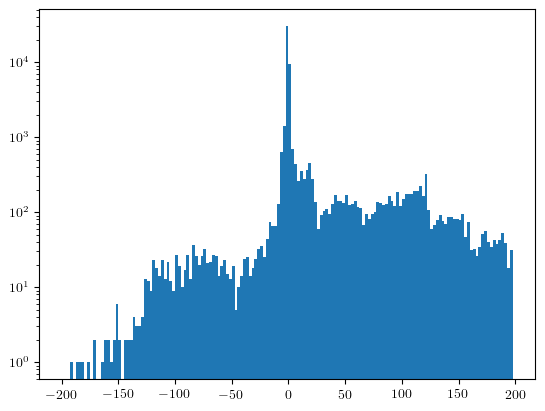

In [206]:
plt.bar((bins[:-1]+bins[1:])/2,
        old_rocof_hist,
        width=(bins[1]-bins[0]))

plt.yscale('log')
plt.show()
